Exercise 1: Data Preparation


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

pd.set_option('display.width', 1000)


#Load the winequality-white.csv and winequality-red.csv into Pandas DataFrames
df_white = pd.read_csv('winequality-white.csv', sep=';')
df_red = pd.read_csv('winequality-red.csv', sep=';')


#add wine_type as an attribute to each DataFrame

df_white['wine_type'] = 'white'
df_red['wine_type'] = 'red'

#Use the apply method and pd.Categorical to encode a new quality_label attribute with categorical values:
#‘low’: quality scores in range [0, 5)
#‘medium’: quality scores in range [5, 7)
#‘high’: quality scores in range [7, 10]


def add_quality_label(quality):
    if quality < 5:
        return 'low'
    elif quality < 7:
        return 'medium'
    else:
        return 'high'   
    
df_white['quality_label'] = df_white['quality'].apply(add_quality_label)
df_red['quality_label'] = df_red['quality'].apply(add_quality_label)

#Merge the red and white wine datasets into a single DataFrame called wines
wines = pd.concat([df_white, df_red], ignore_index=True)

#Re-shuffle records to randomize data points (use sample method with random_state for reproducibility)
wines = wines.sample(frac=1, random_state=50).reset_index(drop=True)

#wyswietlanie
print("First 5 records of the combined wines dataset:")
print(wines.head())

#Generate descriptive statistics for key attributes in both red and white wines using:
print("Descriptive statistics for key attributes in the wines dataset:")
subset_attributes = ['residual sugar', 'total sulfur dioxide', 'sulphates', 'alcohol', 'volatile acidity', 'quality']
print(wines[subset_attributes].describe()) 

print("Descriptive statistics for key attributes in red and white wines separately:")
#Compare statistics across different quality levels (low, medium, high) for these attributes:
subset_attributes = ['alcohol', 'volatile acidity', 'pH', 'quality']
print(wines.groupby('quality_label')[subset_attributes].describe())



First 5 records of the combined wines dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol  quality wine_type quality_label
0            6.1             0.300         0.30             2.1      0.031                 50.0                 163.0  0.98950  3.39       0.43     12.7        7     white          high
1            7.3             0.205         0.31             1.7      0.060                 34.0                 110.0  0.99630  3.72       0.69     10.5        6     white        medium
2           15.6             0.685         0.76             3.7      0.100                  6.0                  43.0  1.00320  2.95       0.68     11.2        7       red          high
3            6.8             0.590         0.10             1.7      0.063                 34.0                  53.0  0.99580  3.41       0.67      9.7        5       red        medium
4            7.1       

Exercise 2: Univariate Analysis


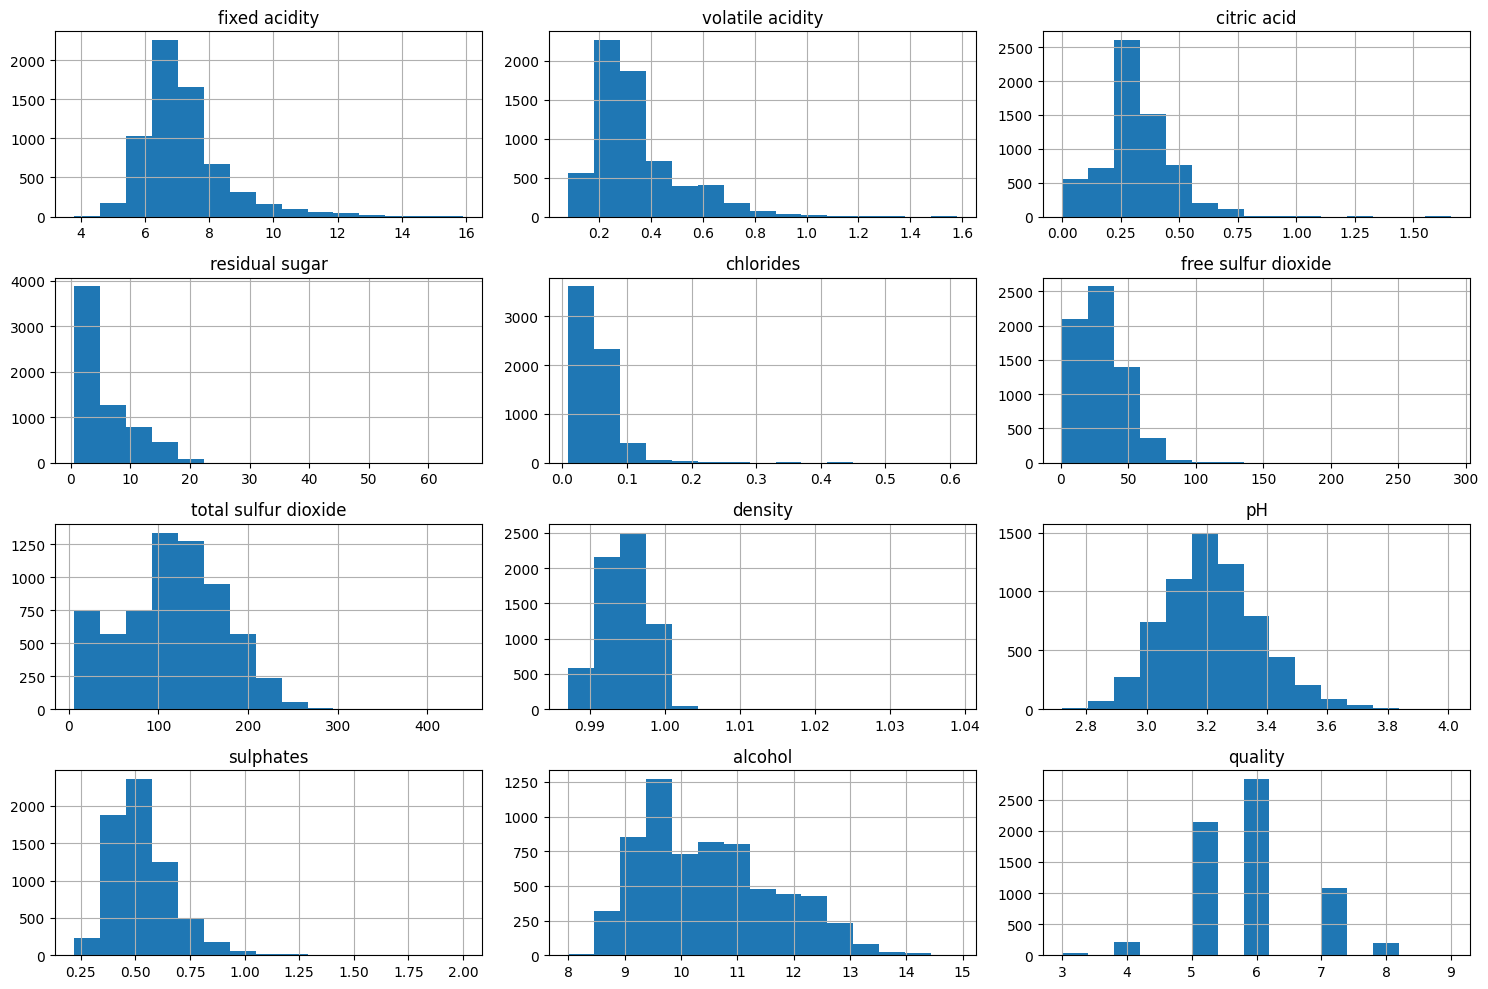

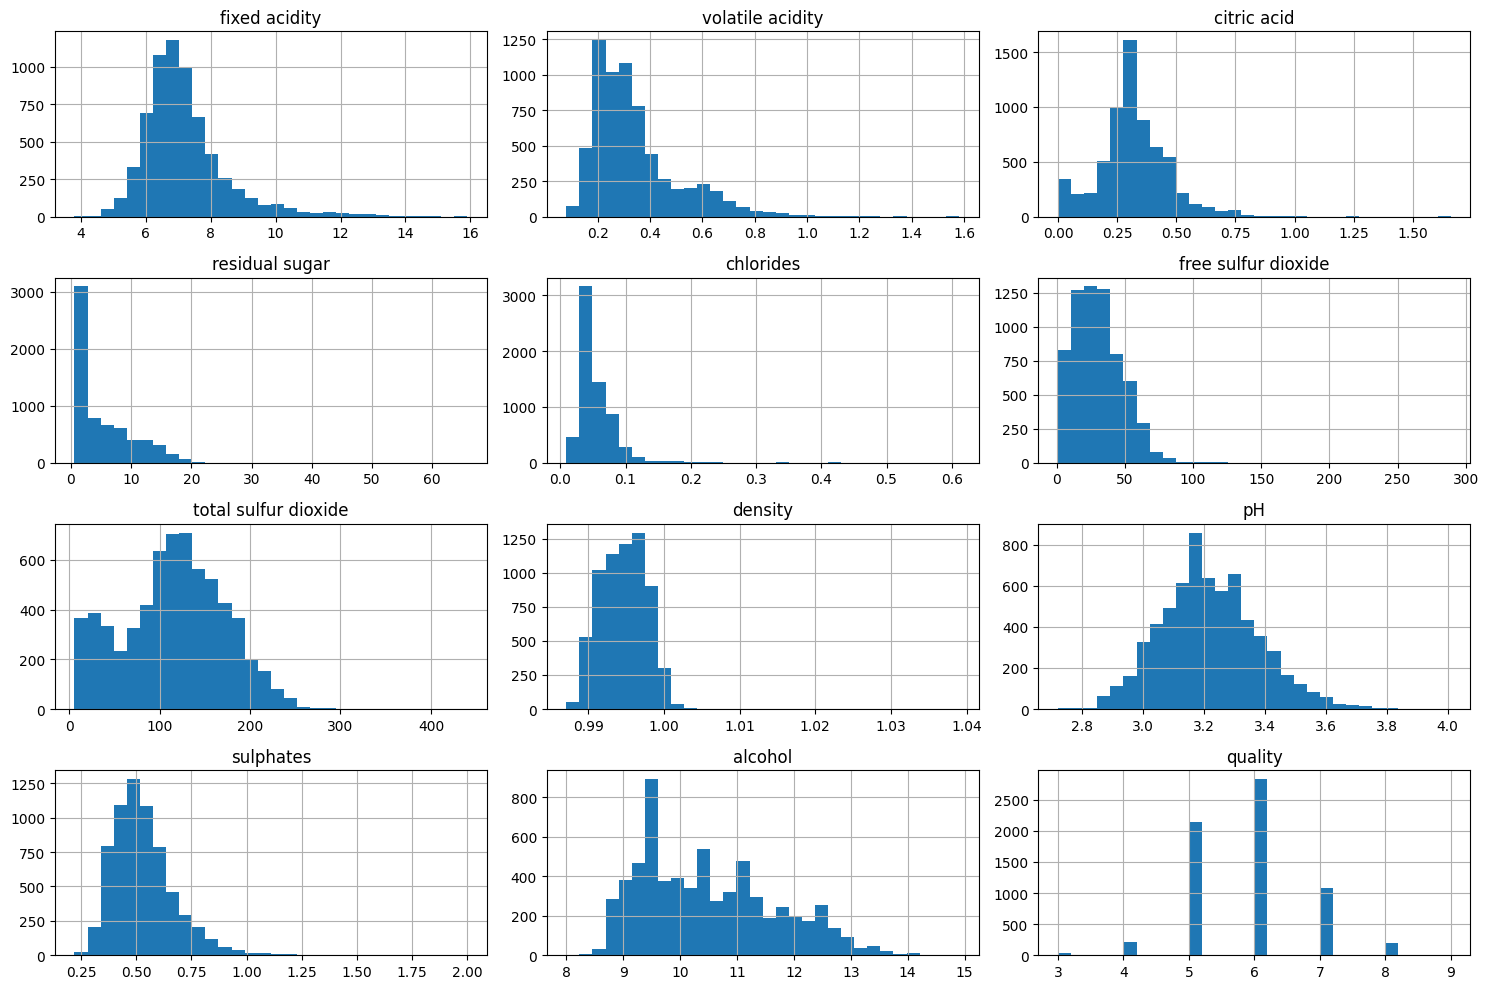

In [7]:
#Generate histograms for all numeric attributes in the wine dataset
numeric_attributes = wines.select_dtypes(include=[np.number]).columns.tolist()
wines[numeric_attributes].hist(bins=15, figsize=(15, 10))
plt.tight_layout()
plt.show()

#Experiment with different bin sizes to see how they affect the visualization
wines[numeric_attributes].hist(bins=30, figsize=(15, 10))
plt.tight_layout()  
plt.show()





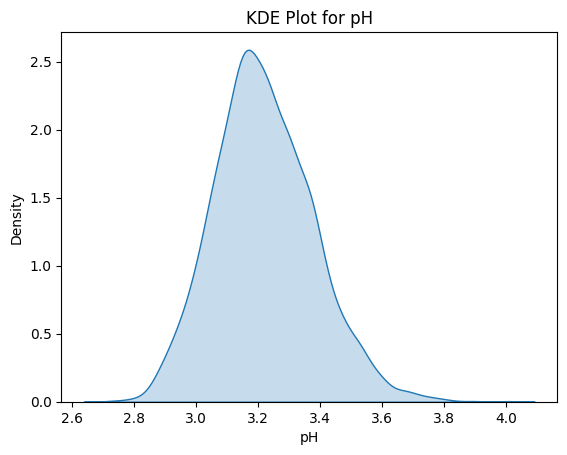

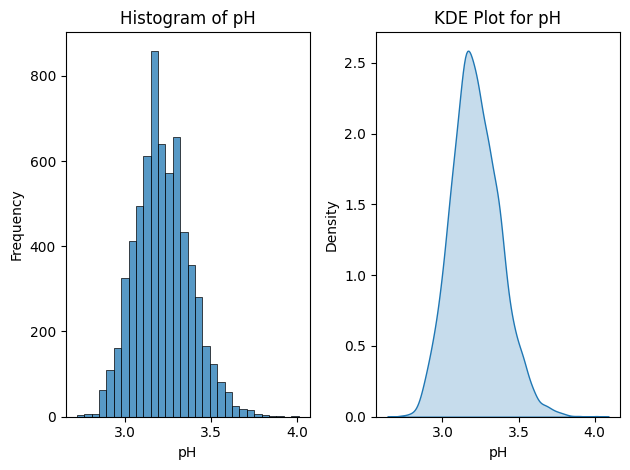

In [13]:
# Choose one continuous attribute (e.g., alcohol content, pH) and create more detailed visualization. Plot it in continuous space using a kernel density estimation (KDE) plot
#KDE to wykres gęstości jądrowej. , czyli wygładzona wersja histogramu, która pozwala zobaczyć "kształt" danych w sposób bardziej ciągły.
attribute = 'pH'
sns.kdeplot(wines[attribute], fill=True)
plt.title(f'KDE Plot for {attribute}')
plt.xlabel(attribute)
plt.ylabel('Density')
plt.show()

#Create a side-by-side comparison of a histogram and KDE plot for the same attribute
plt.subplot(1, 2, 1)
sns.histplot(wines[attribute], bins=30, kde=False)  
plt.title(f'Histogram of {attribute}')
plt.xlabel(attribute)
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
sns.kdeplot(wines[attribute], fill=True)
plt.title(f'KDE Plot for {attribute}')
plt.xlabel(attribute)
plt.ylabel('Density')
plt.tight_layout()
plt.show()  



['wine_type', 'quality_label']


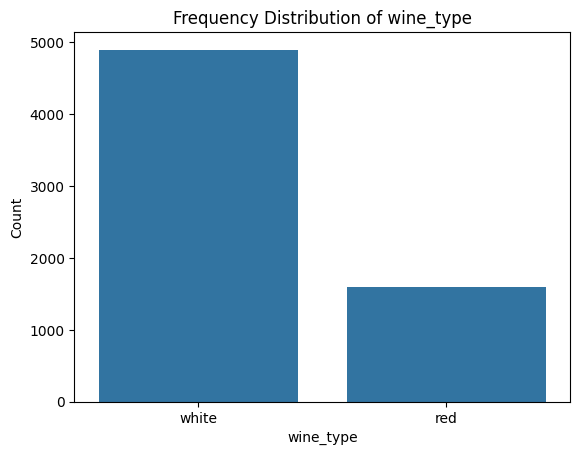

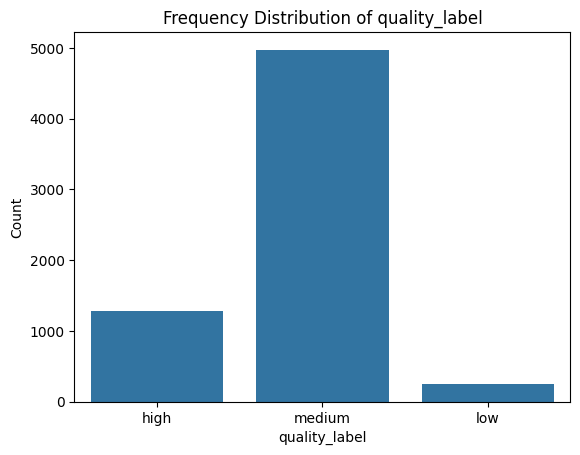

Percentage distribution for wine_type:
wine_type
white    75.388641
red      24.611359
Name: count, dtype: float64

Percentage distribution for quality_label:
quality_label
medium    76.558412
high      19.655225
low        3.786363
Name: count, dtype: float64



In [35]:
#For categorical data like quality or wine type:
categorical_attributes = wines.select_dtypes(include=['object']).columns.tolist()

print(categorical_attributes)

# Create a bar plot showing the frequency distribution /liczebność
for attribute in categorical_attributes:
    sns.countplot(data=wines, x=attribute)
    plt.title(f'Frequency Distribution of {attribute}')
    plt.xlabel(attribute)
    plt.ylabel('Count')
    plt.show()


# Calculate and display the percentage of each category
for attribute in categorical_attributes:
    category_counts = wines[attribute].value_counts()
    category_percentages = (category_counts / len(wines)) * 100
    print(f"Percentage distribution for {attribute}:\n{category_percentages}\n")


# For the quality attribute, visualize the distribution and discuss if the dataset is balanced across quality levels



Exercise 3: Multivariate Analysis


Correlation matrix :
                      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide   density        pH  sulphates   alcohol   quality
fixed acidity              1.000000          0.219008     0.324436       -0.111981   0.298195            -0.282735             -0.329054  0.458910 -0.252700   0.299568 -0.095452 -0.076743
volatile acidity           0.219008          1.000000    -0.377981       -0.196011   0.377124            -0.352557             -0.414476  0.271296  0.261454   0.225984 -0.037640 -0.265699
citric acid                0.324436         -0.377981     1.000000        0.142451   0.038998             0.133126              0.195242  0.096154 -0.329808   0.056197 -0.010493  0.085532
residual sugar            -0.111981         -0.196011     0.142451        1.000000  -0.128940             0.402871              0.495482  0.552517 -0.267320  -0.185927 -0.359415 -0.036980
chlorides                  0.298195    

<Axes: >

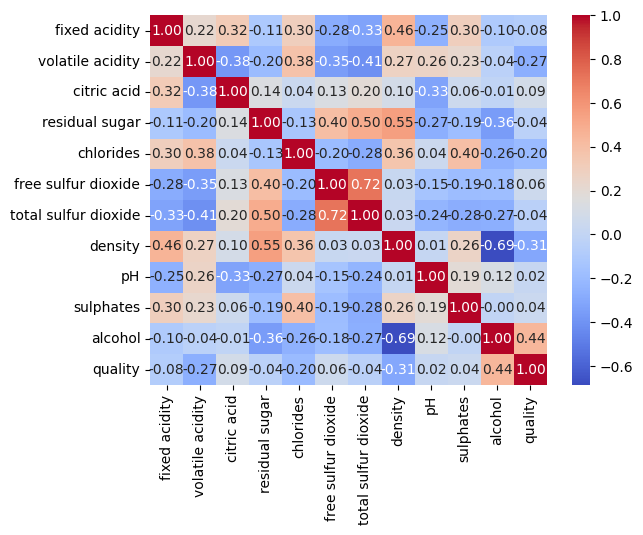

In [47]:
# One of the best ways to identify relationships between different data attributes is through correlation analysis:

# Create a correlation matrix for all numeric attributes using the pandas corr() method
numeric_attributes = wines.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = wines[numeric_attributes].corr()
print("Correlation matrix :")
print(correlation_matrix)

# Visualize the correlation matrix as a heatmap using seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Identify the attributes with the strongest positive and negative correlations to quality
# Write a brief interpretation of the key relationships you observe

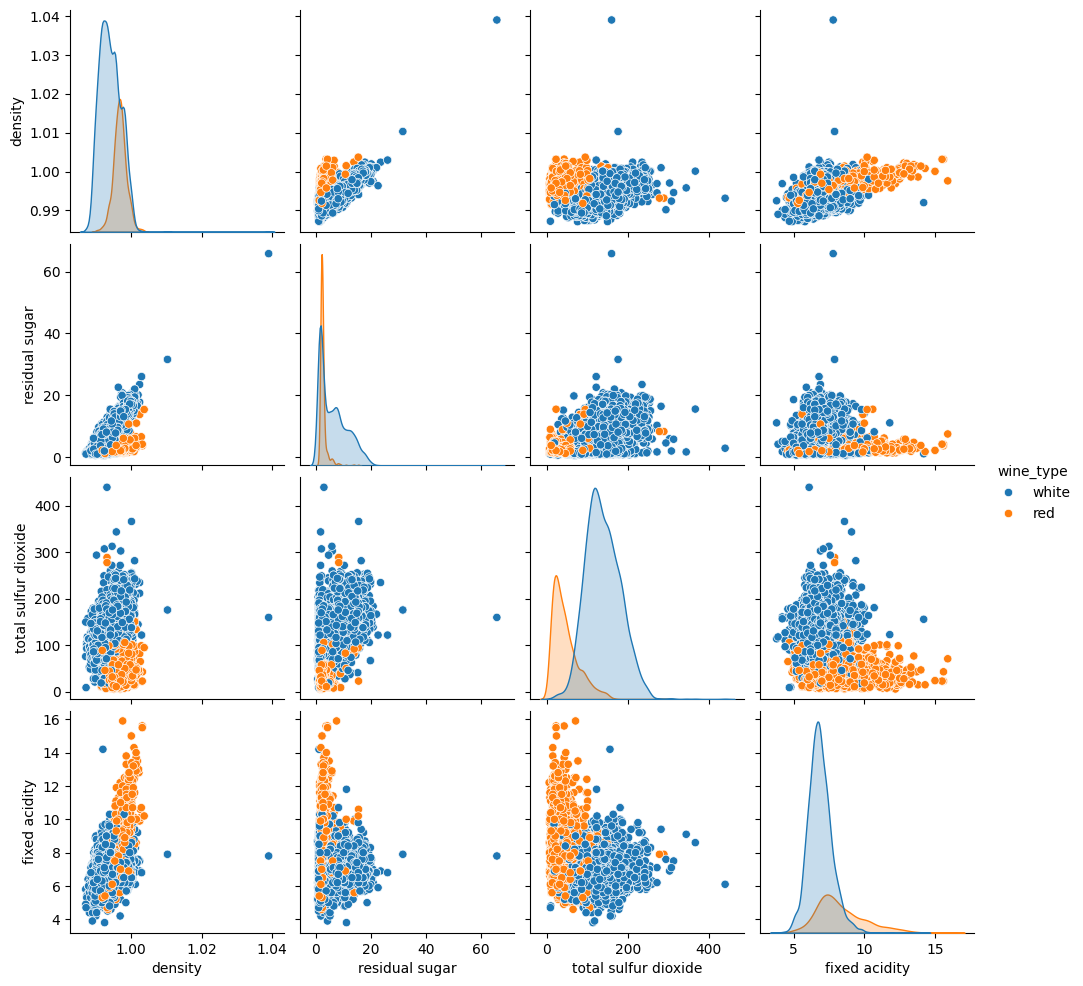

In [ ]:
# Visualize relationships between multiple variables at once:

# Create a pairplot for 4 attributes of your choosing (e.g., density, residual sugar, total sulfur dioxide, fixed acidity)
# Add color coding to distinguish between red and white wines
sns.pairplot(wines, vars=['density', 'residual sugar', 'total sulfur dioxide', 'fixed acidity'], hue='wine_type')

# Identify any visible patterns or clusters in the data
# Discuss which attributes show the clearest separation between wine types

<Axes: >

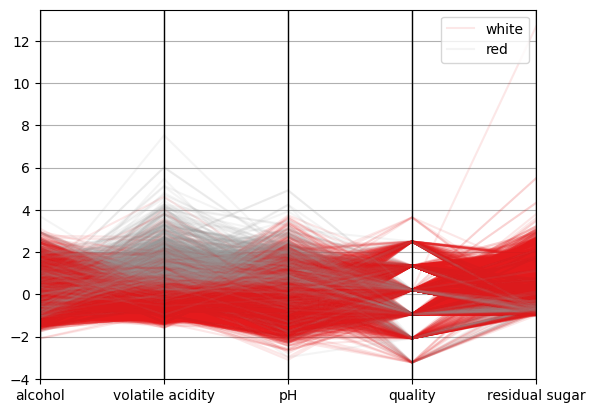

In [61]:
# Parallel coordinates provide another way to visualize multiple attributes together:

# Select 5-6 key attributes and create a parallel coordinates plot
key_attributes = ['alcohol', 'volatile acidity', 'pH', 'quality', 'residual sugar']
subset = wines[key_attributes].copy()

# Scale the data appropriately before plotting (hint: use StandardScaler from sklearn)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(subset)

scaled_df=pd.DataFrame(scaled_data, columns=key_attributes)
scaled_df['wine_type'] = wines['wine_type'].values

pd.plotting.parallel_coordinates(scaled_df, 'wine_type', colormap='Set1', alpha=0.1)



# Color the lines by wine type
# Analyze how the attributes differ between red and white wines

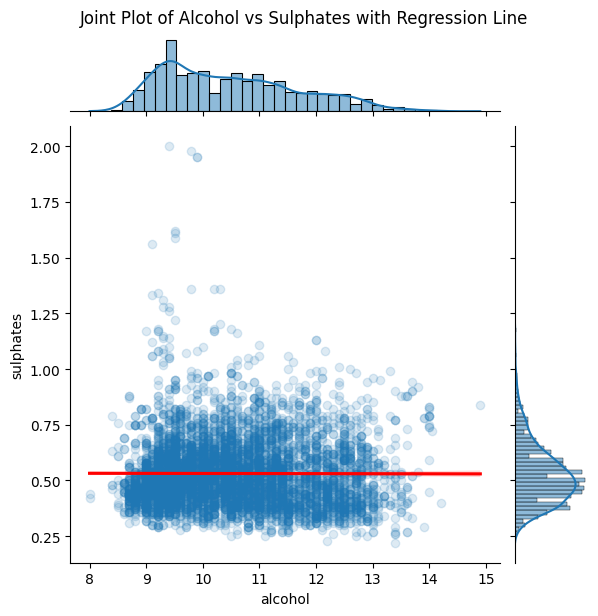

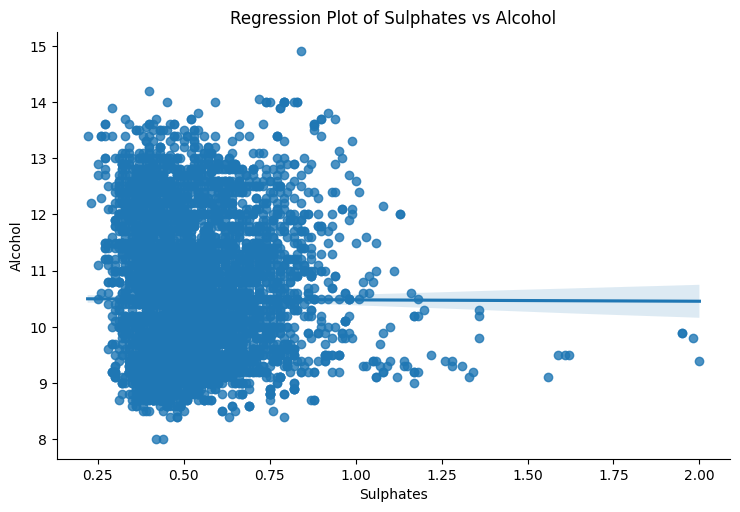

Correlation coefficient between sulphates and alcohol: -0.00


In [82]:
# Two Continuous Variables:
# Create a scatter plot and joint plot for two continuous variables (e.g., sulphates and alcohol)

# sns.scatterplot(data=wines, x='sulphates', y='alcohol', hue='wine_type')
# plt.title('Scatter Plot of Sulphates vs Alcohol')
# plt.xlabel('Sulphates')
# plt.ylabel('Alcohol')
# plt.show()

# kind='reg' dodaje linię regresji oraz wykresy gęstości/histogramy na brzegach
sns.jointplot(data=wines, x='alcohol', y='sulphates', kind='reg', 
              joint_kws={'scatter_kws': {'alpha': 0.15}}, 
              line_kws={'color': 'red'})

plt.suptitle('Joint Plot of Alcohol vs Sulphates with Regression Line', y=1.02)
plt.show()


# Add a regression line to identify any linear relationship
sns.lmplot(data=wines, x='sulphates', y='alcohol',  aspect=1.5) #hue='wine_type - mozna dodac
plt.title('Regression Plot of Sulphates vs Alcohol')
plt.xlabel('Sulphates')
plt.ylabel('Alcohol')
plt.show()

# Calculate and report the correlation coefficient
correlation = wines['sulphates'].corr(wines['alcohol'])
print(f"Correlation coefficient between sulphates and alcohol: {correlation:.2f}")

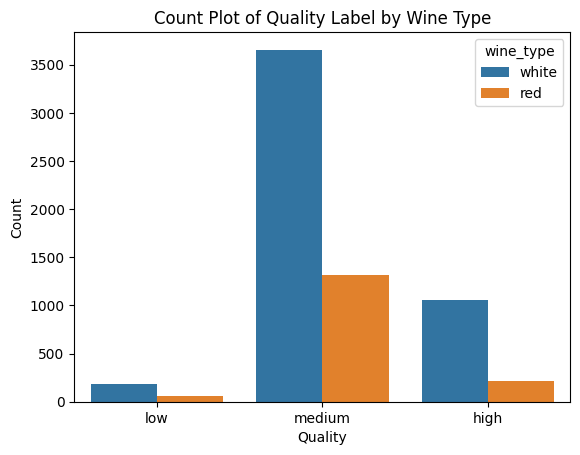

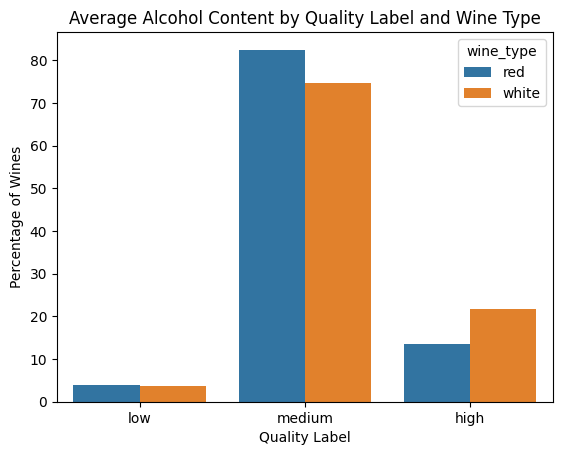

In [107]:
# Two Categorical Variables:
# Create visualizations showing the relationship between wine type and quality

sns.countplot(data=wines, x='quality_label', hue='wine_type', order=['low', 'medium', 'high'])
plt.title('Count Plot of Quality Label by Wine Type')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

pct_data = wines.groupby('wine_type')['quality_label'].value_counts(normalize=True).mul(100).reset_index(name='percentage')

sns.barplot(data=pct_data, x='quality_label', y='percentage', hue='wine_type', order=['low', 'medium', 'high'],)
plt.title('Average Alcohol Content by Quality Label and Wine Type')
plt.xlabel('Quality Label')
plt.ylabel('Percentage of Wines')
plt.show()


# Use appropriate plots (bar charts, count plots, etc.)
# Analyze whether red or white wines tend to have higher quality ratings

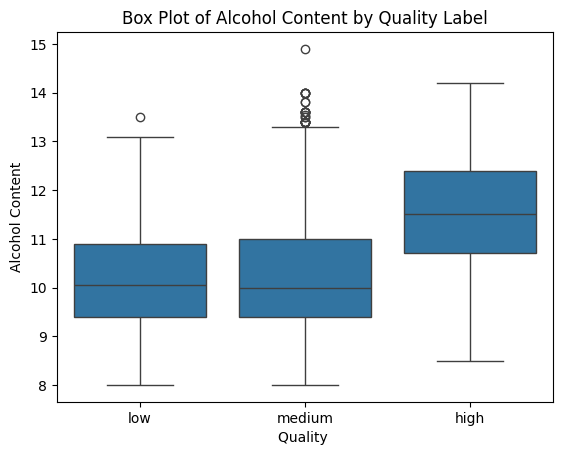

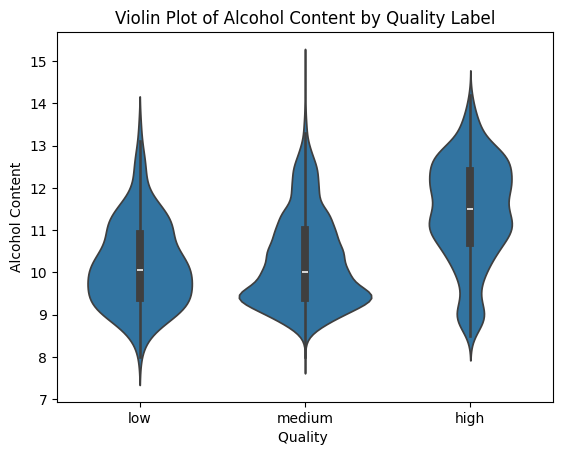

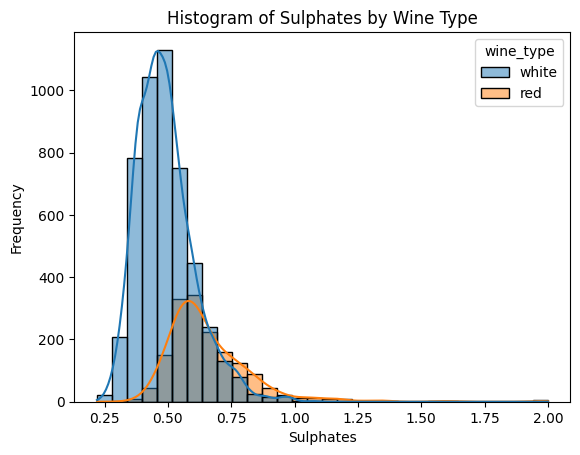

In [113]:
# Mixed Variable Types (Continuous & Categorical):
# Create box plots and violin plots showing how a continuous variable (e.g., alcohol content) varies across different quality levels

sns.boxplot(data=wines, x='quality_label', y='alcohol',order=['low', 'medium', 'high'])
plt.title('Box Plot of Alcohol Content by Quality Label')
plt.xlabel('Quality ')
plt.ylabel('Alcohol Content')
plt.show()

sns.violinplot(data=wines, x='quality_label', y='alcohol', order=['low', 'medium', 'high'])
plt.title('Violin Plot of Alcohol Content by Quality Label')
plt.xlabel('Quality ')
plt.ylabel('Alcohol Content')
plt.show()

# Create separate histograms for a continuous variable (e.g., sulphates) grouped by wine type

sns.histplot(data=wines, x='sulphates', hue='wine_type', bins=30, kde=True)
plt.title('Histogram of Sulphates by Wine Type')
plt.xlabel('Sulphates')
plt.ylabel('Frequency')
plt.show()

# Discuss the key differences you observe between groups

Exercise 4: Multidimensional Visualization


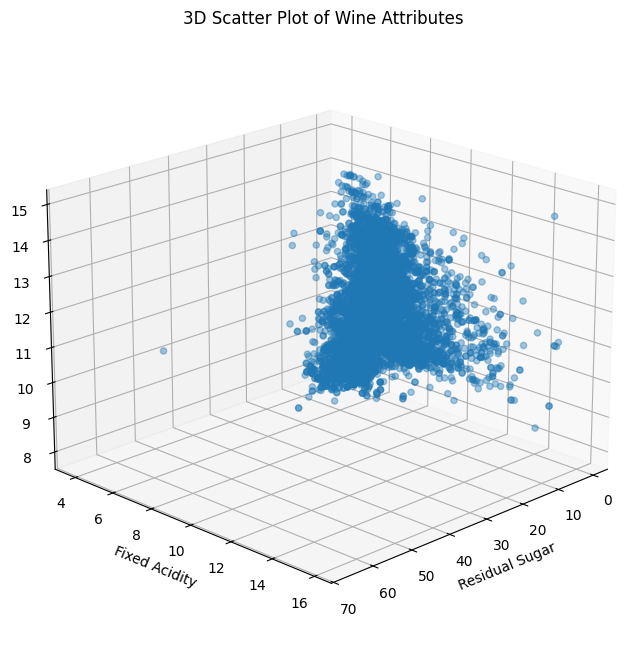

In [163]:
# Three Continuous Variables:
# Create a 3D scatter plot with three continuous variables of your choice (e.g., residual sugar, fixed acidity, and alcohol)
# 1. Przygotowanie danych i płótna 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 2. Wybór atrybutów
x = wines['residual sugar']
y = wines['fixed acidity']
z = wines['alcohol']


scatter = ax.scatter(x, y, z, alpha=0.4)

# 5. Opisy osi
ax.set_xlabel('Residual Sugar')
ax.set_ylabel('Fixed Acidity')
ax.set_zlabel('Alcohol')
plt.title('3D Scatter Plot of Wine Attributes')

# Experiment with viewing angles to best reveal the data structure


# elev - kąt elewacji (wysokość nad poziomem 'gruntu')
# azim - kąt azymutu (obrót wokół osi pionowej)

ax.view_init(elev=20, azim=45)

# Discuss any patterns, clusters, or relationships you observe in three-dimensional space

<Axes: xlabel='alcohol', ylabel='fixed acidity'>

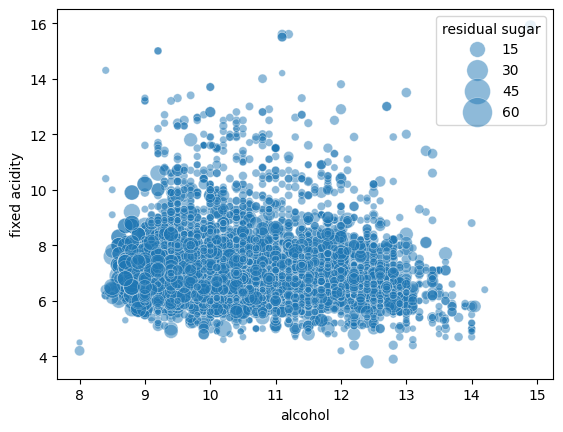

In [165]:
# Size as a Third Dimension:
# Create a 2D scatter plot where the size of points represents a third variable
# Use residual sugar as the size indicator for points in a plot of two other variables
sns.scatterplot(data=wines, x='alcohol', y='fixed acidity', size='residual sugar', sizes=(20, 500), alpha=0.5)

# Explain the advantages and limitations of using size to represent a dimension

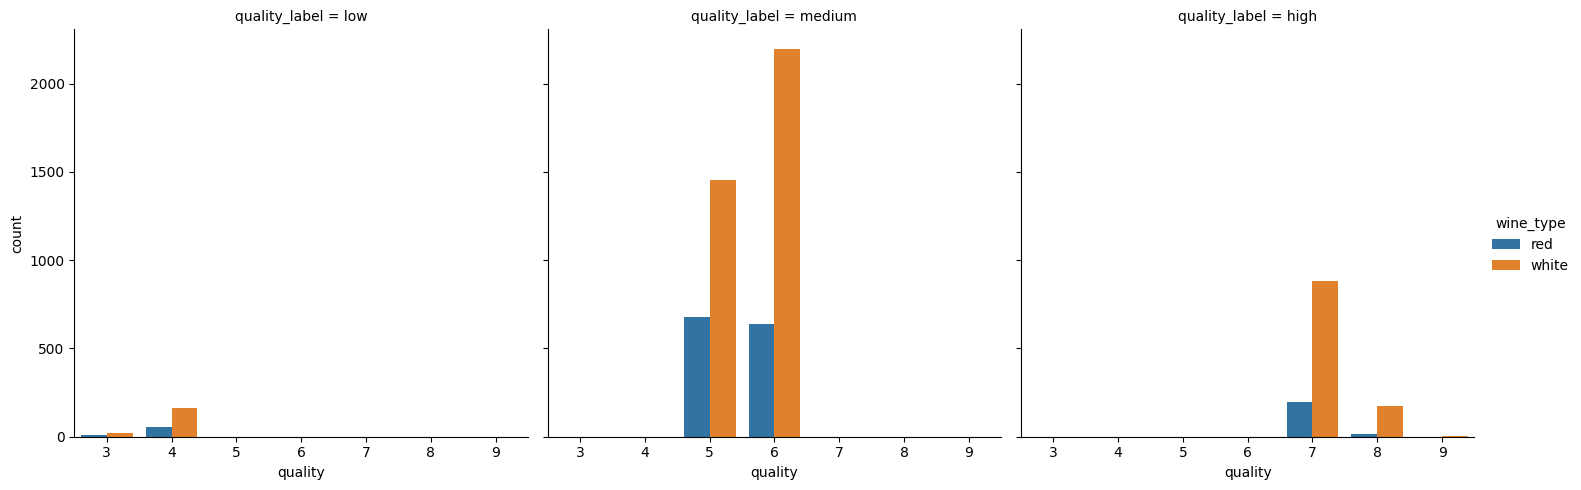

In [168]:
# Three Categorical Dimensions:
# Use a facet plot (e.g., seaborn’s factorplot or catplot) to visualize the relationship between quality, wine type, and quality label

sns.catplot(data=wines, x='quality', hue='wine_type', col='quality_label', kind='count', col_order=['low', 'medium', 'high'])


# Analyze how the different categorical dimensions interact

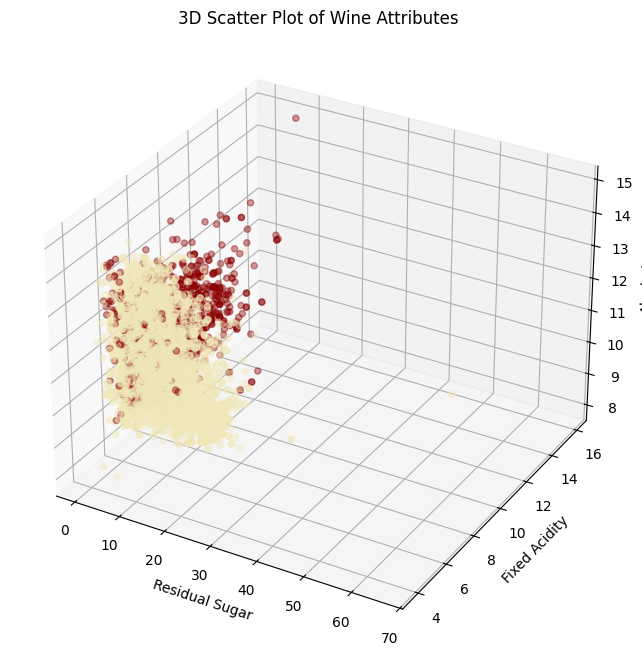

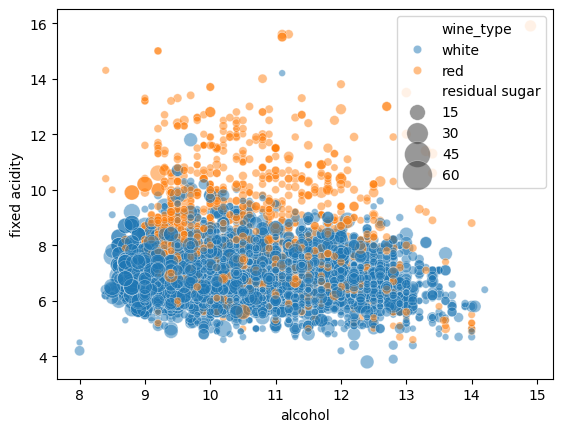

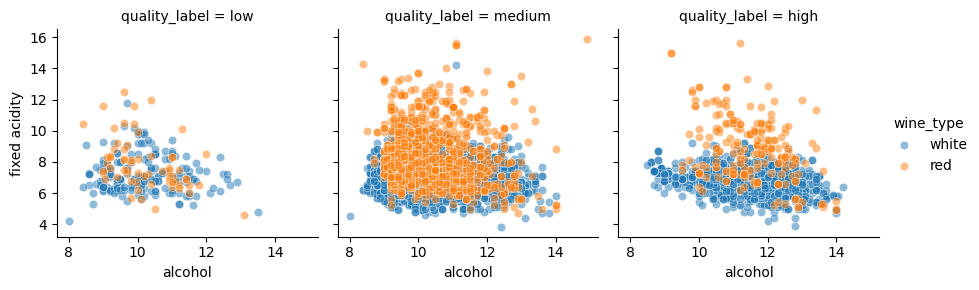

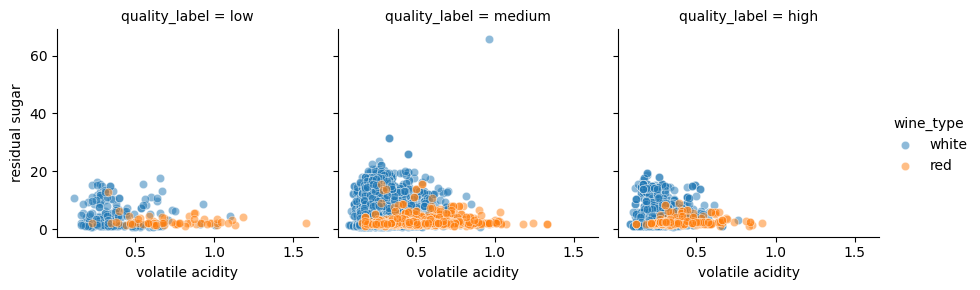

In [178]:
# 2. Four-Dimensional Visualization
# Create visualizations that incorporate four dimensions:

# 3D scatter plot with color as the fourth dimension:
# Create a 3D scatter plot where point colors represent wine type
# Interpret how wine type relates to the three continuous variables

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = wines['residual sugar']
y = wines['fixed acidity']
z = wines['alcohol']

# 3. Tworzenie wykresu punktowego
# Kolorujemy punkty według typu wina dla lepszej przejrzystości
colors = wines['wine_type'].map({'red': '#8b0000', 'white': "#f0e7b8"})

scatter = ax.scatter(x, y, z, c=colors, alpha=0.4)

# 5. Opisy osi
ax.set_xlabel('Residual Sugar')
ax.set_ylabel('Fixed Acidity')
ax.set_zlabel('Alcohol')
plt.title('3D Scatter Plot of Wine Attributes')
plt.show()

# Bubble chart with size and color:
# Create a scatter plot where both size and color encode different variables
# Use appropriate variables that might reveal interesting patterns (e.g., position: acidity & alcohol; size: residual sugar; color: wine type)
sns.scatterplot(data=wines, x='alcohol', y='fixed acidity', size='residual sugar', sizes=(20, 500), hue='wine_type', alpha=0.5)
plt.show()

# FacetGrid for faceted visualization:
# Create a FacetGrid with quality label as columns, wine type as hue, and plot two continuous variables
#tworzymy siatkę fasetową, gdzie każda kolumna reprezentuje inny poziom jakości wina (low, medium, high), a kolor punktów wskazuje na typ wina (red lub white). Na osi X umieszczamy zawartość alkoholu, a na osi Y kwasowość stałą. Dzięki temu możemy zobaczyć, jak te dwie cechy różnią się w zależności od jakości i typu wina.
g = sns.FacetGrid(wines, col='quality_label', hue='wine_type', col_order=['low', 'medium', 'high'])
# 2. Mapujemy wykres punktowy na każdą fasetę
g.map(sns.scatterplot, 'alcohol', 'fixed acidity', alpha=0.5)
g.add_legend()
plt.show()

# Repeat with different continuous variables

g = sns.FacetGrid(wines, col='quality_label', hue='wine_type', col_order=['low', 'medium', 'high'])
g.map(sns.scatterplot, 'volatile acidity', 'residual sugar', alpha=0.5)
g.add_legend()
plt.show()
# Compare how variable relationships differ across facets

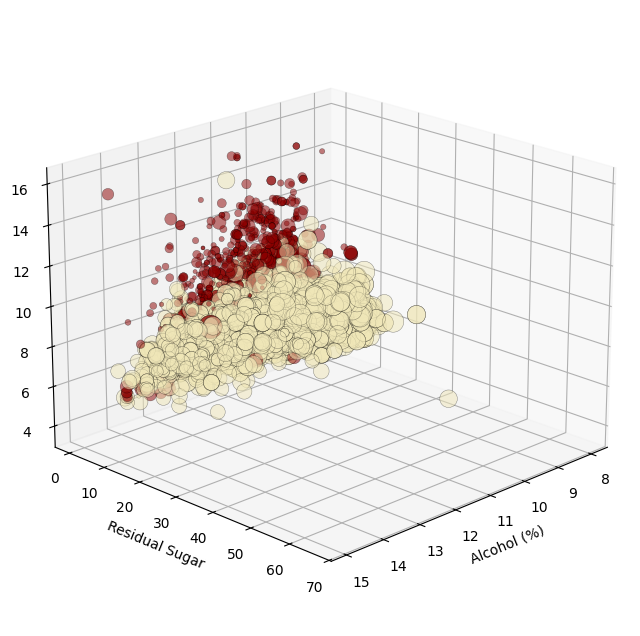

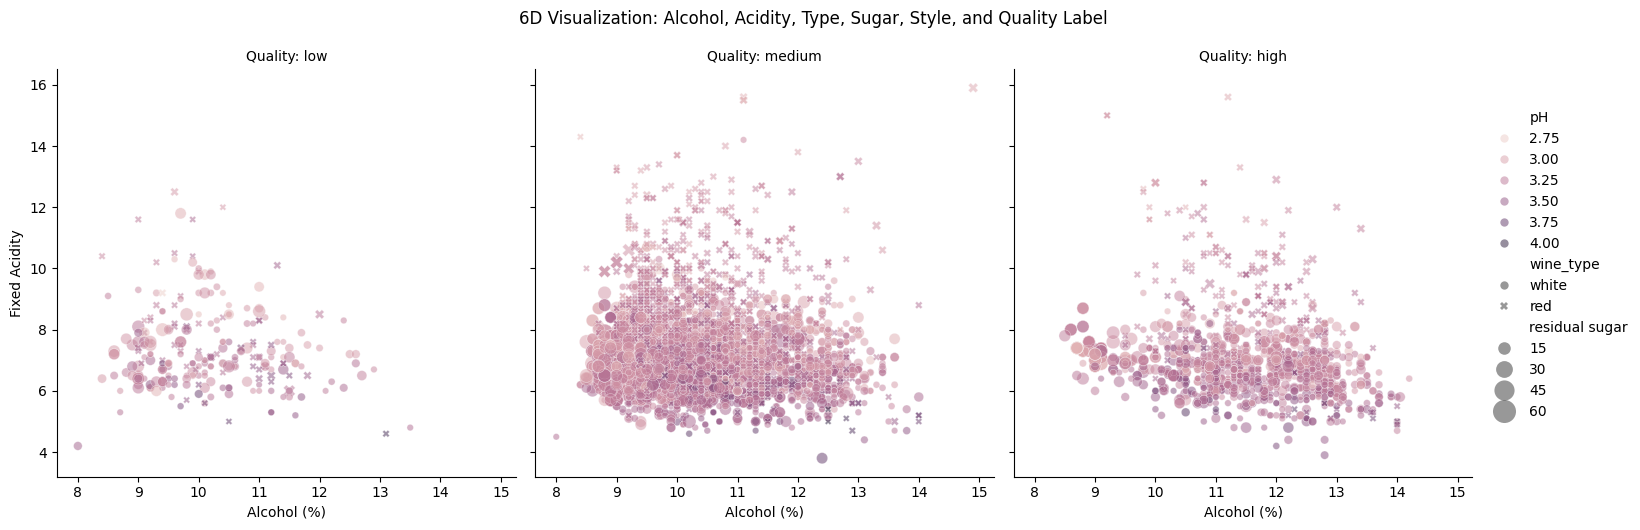

In [206]:
# 3. Five and Six-Dimensional Visualization
# Push the boundaries of visualization with high-dimensional techniques:

# Create a visualization with five dimensions using:
# x, y, z positions (3D scatter)
# color (wine type)
# size (total sulfur dioxide)
# Interpret what insights can be gained from this complex visualization

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x= wines['alcohol']
y = wines['residual sugar']
z = wines['fixed acidity']

colors = wines['wine_type'].map({'red': '#8b0000', 'white': "#f0e7b8"})
sizes = wines['total sulfur dioxide']  

scatter = ax.scatter(x, y, z, c=colors, s=sizes,  alpha=0.5, edgecolors='black', linewidth=0.3)

ax.set_xlabel('Alcohol (%)')
ax.set_ylabel('Residual Sugar')
ax.set_zlabel('Fixed Acidity')
ax.view_init(elev=20, azim=45)
plt.show()

# Create a visualization with six dimensions by adding:
# Faceting (by quality or quality label)
# Different marker shapes based on another categorical variable
# Discuss whether the added complexity enhances understanding or creates confusion

g = sns.relplot(
    data=wines,
    x='alcohol', 
    y='fixed acidity',
    hue='pH',       # Kolor 
    size='residual sugar', # Wielkość 
    style='wine_type',     # Kształt markera 
    col='quality_label',   # Fasetowanie/Kolumny 
    sizes=(20, 300), 
    alpha=0.5,
    col_order=['low', 'medium', 'high'],
)

g.fig.suptitle('6D Visualization: Alcohol, Acidity, Type, Sugar, Style, and Quality Label', y=1.05)
g.set_axis_labels("Alcohol (%)", "Fixed Acidity")
g.set_titles("Quality: {col_name}")

plt.show()

